# Gender Equality & Workforce Diversity Analytics  
## SDG Goal 5 — AI Data Analytics Project  

This project analyzes workforce diversity, gender pay gap, promotions, and leadership trends using Data Analytics and Machine Learning.

###  Objectives:
- Identify gender pay gap
- Analyze promotion bias
- Study workforce distribution
- Build ML model for promotion prediction
- Segment employees using clustering

IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor': '#13161e',
    'axes.edgecolor': '#252a38',
    'axes.labelcolor': '#8892a4',
    'xtick.color': '#8892a4',
    'ytick.color': '#8892a4',
    'text.color': '#f0f2f8',
    'grid.color': '#252a38',
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
})
COLORS = {'Male': '#6b8cff', 'Female': '#e85d8a', 'Non-Binary': '#a78bfa'}

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


DATA GENERATION

In [8]:
df_raw = pd.read_csv('raw_gender_equality_dataset.csv')
print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nDtype summary:\n{df_raw.dtypes}")
print(f"\nNull counts:\n{df_raw.isnull().sum()}")
print(f"\nFirst 5 rows:\n{df_raw.head()}")

Shape: (120000, 19)

Columns: ['Employee_ID', 'Gender', 'Age', 'Department', 'Job_Level', 'Education', 'Experience_Years', 'Years_at_Company', 'Region', 'Annual_Salary', 'Bonus', 'Performance_Rating', 'Promoted_Last_Year', 'Leadership_Role', 'Parental_Leave_Taken', 'Training_Hours', 'Turnover', 'Hiring_Year', 'Gender_Equality_Category']

Dtype summary:
Employee_ID                  object
Gender                       object
Age                         float64
Department                   object
Job_Level                    object
Education                    object
Experience_Years              int64
Years_at_Company              int64
Region                       object
Annual_Salary               float64
Bonus                       float64
Performance_Rating           object
Promoted_Last_Year            int64
Leadership_Role               int64
Parental_Leave_Taken          int64
Training_Hours              float64
Turnover                      int64
Hiring_Year                   int

 DATA CLEANING & PROCESSING

In [9]:
df = df_raw.copy()

# 3.1 Standardise Gender column
gender_map = {'male':'Male','MALE':'Male','M':'Male','m':'Male',
              'female':'Female','FEMALE':'Female','F':'Female','f':'Female',
              'non-binary':'Non-Binary','NB':'Non-Binary'}
df['Gender'] = df['Gender'].replace(gender_map)
df['Gender'] = df['Gender'].where(df['Gender'].isin(['Male','Female','Non-Binary']), np.nan)

# 3.2 Age: remove out-of-range values, fill with median
df.loc[(df['Age'] < 18) | (df['Age'] > 70), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# 3.3 Experience: remove negatives
df.loc[df['Experience_Years'] < 0, 'Experience_Years'] = np.nan
df['Experience_Years'] = df['Experience_Years'].fillna(df['Experience_Years'].median()).astype(int)

# 3.4 Salary/Bonus: impute with dept+level median
for col in ['Annual_Salary', 'Bonus']:
    df[col] = df.groupby(['Department','Job_Level'])[col]\
                .transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median()).astype(int)

df['Training_Hours'] = df['Training_Hours'].fillna(df['Training_Hours'].median()).astype(int)

# 3.5 Drop rows still missing Gender
df.dropna(subset=['Gender'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Cleaned shape: {df.shape} | Remaining nulls: {df.isnull().sum().sum()}")
df.to_csv('cleaned_gender_data.csv', index=False)

✅ Cleaned shape: (119932, 19) | Remaining nulls: 0


KEY METRICS CALCULATION

In [10]:
df['Total_Compensation'] = df['Annual_Salary'] + df['Bonus']
df['Pay_Per_Experience']  = (df['Annual_Salary'] / (df['Experience_Years'] + 1)).round(2)

dept_gender_med = df.groupby(['Department','Gender'])['Annual_Salary'].transform('median')
dept_med        = df.groupby('Department')['Annual_Salary'].transform('median')
df['Pay_Gap_Index'] = ((dept_gender_med - dept_med) / dept_med * 100).round(2)

df['Diversity_Score'] = (
    (df['Gender'] == 'Female').astype(int) * 0.4 +
    df['Promoted_Last_Year'] * 0.30 +
    (df['Training_Hours'] / 120) * 0.30
).round(4)

print("✅ Feature engineering complete. New features:", ['Total_Compensation','Pay_Per_Experience','Pay_Gap_Index','Diversity_Score'])

✅ Feature engineering complete. New features: ['Total_Compensation', 'Pay_Per_Experience', 'Pay_Gap_Index', 'Diversity_Score']


In [11]:
male   = df[df['Gender'] == 'Male']
female = df[df['Gender'] == 'Female']
nb     = df[df['Gender'] == 'Non-Binary']

kpis = {
    'Gender Pay Gap (%)':               round((male['Annual_Salary'].median() - female['Annual_Salary'].median()) / male['Annual_Salary'].median() * 100, 2),
    'Male Median Salary':               int(male['Annual_Salary'].median()),
    'Female Median Salary':             int(female['Annual_Salary'].median()),
    'Female Workforce Participation (%)': round(len(female)/len(df)*100, 2),
    'Female Leadership %':              round((df[df['Leadership_Role']==1]['Gender']=='Female').sum() / df['Leadership_Role'].sum() * 100, 2),
    'Male Promotion Rate (%)':          round(male['Promoted_Last_Year'].mean()*100, 2),
    'Female Promotion Rate (%)':        round(female['Promoted_Last_Year'].mean()*100, 2),
    'Diversity Index (Simpson ×100)':   round((1 - sum(n*(n-1) for n in df['Gender'].value_counts())) / (len(df)*(len(df)-1)) * 100, 2),
    'Hiring Ratio M:F':                 f"{round(len(male)/len(df)*100,1)} : {round(len(female)/len(df)*100,1)}",
    'Male Turnover (%)':                round(male['Turnover'].mean()*100, 2),
    'Female Turnover (%)':              round(female['Turnover'].mean()*100, 2),
    'Avg Training Hours — Male':        round(male['Training_Hours'].mean(), 1),
    'Avg Training Hours — Female':      round(female['Training_Hours'].mean(), 1),
}

print("=" * 50)
print("  KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 50)
for k, v in kpis.items():
    print(f"  {k:<42} {v}")

metrics_df = pd.DataFrame([kpis])
metrics_df.to_csv('gender_metrics.csv', index=False)
print("\n✅ KPIs saved to gender_metrics.csv")

  KEY PERFORMANCE INDICATORS (KPIs)
  Gender Pay Gap (%)                         26.4
  Male Median Salary                         99341
  Female Median Salary                       73116
  Female Workforce Participation (%)         42.13
  Female Leadership %                        33.14
  Male Promotion Rate (%)                    21.88
  Female Promotion Rate (%)                  19.61
  Diversity Index (Simpson ×100)             -48.06
  Hiring Ratio M:F                           55.0 : 42.1
  Male Turnover (%)                          15.11
  Female Turnover (%)                        17.96
  Avg Training Hours — Male                  44.3
  Avg Training Hours — Female                37.6

✅ KPIs saved to gender_metrics.csv


EXPLORATORY DATA ANALYSIS (EDA)

✅ EDA plots saved


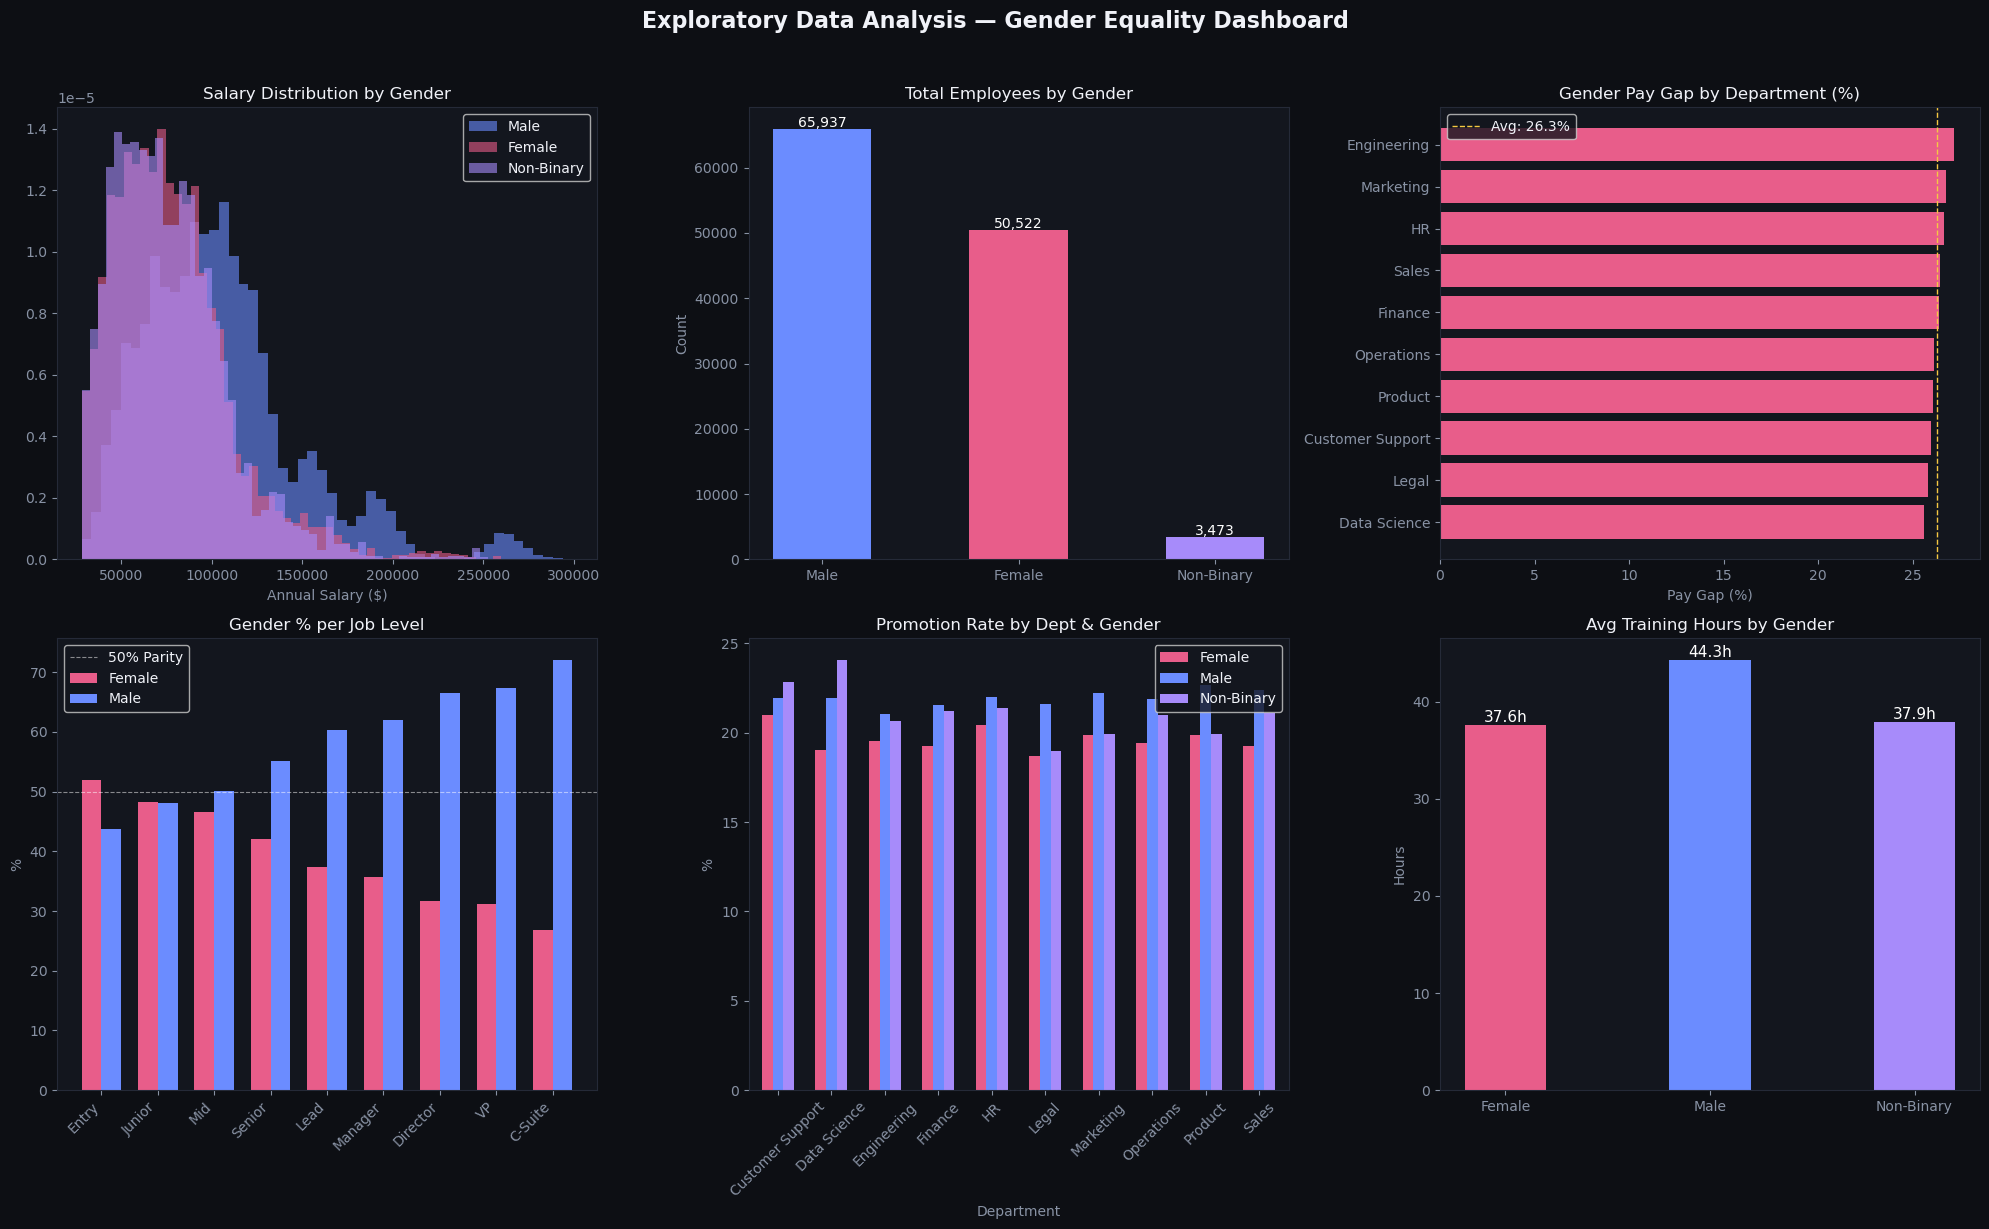

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Exploratory Data Analysis — Gender Equality Dashboard', fontsize=16, fontweight='bold', color='#f0f2f8', y=1.02)

# Plot 1: Salary distribution
ax = axes[0,0]
for g, c in COLORS.items():
    subset = df[df['Gender'] == g]['Annual_Salary']
    ax.hist(subset, bins=50, alpha=0.6, label=g, color=c, density=True)
ax.set_title('Salary Distribution by Gender'); ax.set_xlabel('Annual Salary ($)'); ax.legend()

# Plot 2: Gender composition
ax = axes[0,1]
vc = df['Gender'].value_counts()
bars = ax.bar(vc.index, vc.values, color=[COLORS[g] for g in vc.index], width=0.5, edgecolor='none')
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f'{val:,}', ha='center', fontsize=10, color='white')
ax.set_title('Total Employees by Gender'); ax.set_ylabel('Count')

# Plot 3: Pay gap by dept
ax = axes[0,2]
pay_gap = df.groupby('Department').apply(lambda x: (x[x.Gender=='Male']['Annual_Salary'].median() - x[x.Gender=='Female']['Annual_Salary'].median()) / x[x.Gender=='Male']['Annual_Salary'].median() * 100).sort_values(ascending=True)
bars = ax.barh(pay_gap.index, pay_gap.values, color='#e85d8a', edgecolor='none')
ax.set_title('Gender Pay Gap by Department (%)'); ax.set_xlabel('Pay Gap (%)')
ax.axvline(pay_gap.mean(), color='#f5c842', linestyle='--', linewidth=1, label=f'Avg: {pay_gap.mean():.1f}%')
ax.legend()

# Plot 4: Leadership pipeline
ax = axes[1,0]
levels = ['Entry','Junior','Mid','Senior','Lead','Manager','Director','VP','C-Suite']
f_pct = [df[(df['Job_Level']==l) & (df['Gender']=='Female')].shape[0] / df[df['Job_Level']==l].shape[0] * 100 for l in levels]
m_pct = [df[(df['Job_Level']==l) & (df['Gender']=='Male')].shape[0] / df[df['Job_Level']==l].shape[0] * 100 for l in levels]
x = np.arange(len(levels)); width = 0.35
ax.bar(x-width/2, f_pct, width, label='Female', color=COLORS['Female'], edgecolor='none')
ax.bar(x+width/2, m_pct, width, label='Male', color=COLORS['Male'], edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(levels, rotation=45, ha='right')
ax.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.5, label='50% Parity')
ax.set_title('Gender % per Job Level'); ax.set_ylabel('%'); ax.legend()

# Plot 5: Promotion rate
ax = axes[1,1]
promo = df.groupby(['Department','Gender'])['Promoted_Last_Year'].mean().mul(100).unstack()
promo.plot(kind='bar', ax=ax, color=[COLORS[g] for g in promo.columns], edgecolor='none', width=0.6)
ax.set_title('Promotion Rate by Dept & Gender'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=45); ax.legend()

# Plot 6: Training hours
ax = axes[1,2]
training = df.groupby('Gender')['Training_Hours'].mean()
bars = ax.bar(training.index, training.values, color=[COLORS[g] for g in training.index], width=0.4, edgecolor='none')
for bar, val in zip(bars, training.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}h', ha='center', fontsize=11, color='white')
ax.set_title('Avg Training Hours by Gender'); ax.set_ylabel('Hours')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
print("✅ EDA plots saved")

 ML MODEL (PROMOTION PREDICTION)


  FINAL IMPROVED MODEL: PROMOTION PREDICTION

ROC-AUC: 0.6061
F1 Score: 0.3698

Classification Report:

              precision    recall  f1-score   support

Not Promoted       0.87      0.28      0.43     18972
    Promoted       0.24      0.84      0.37      5015

    accuracy                           0.40     23987
   macro avg       0.55      0.56      0.40     23987
weighted avg       0.74      0.40      0.42     23987



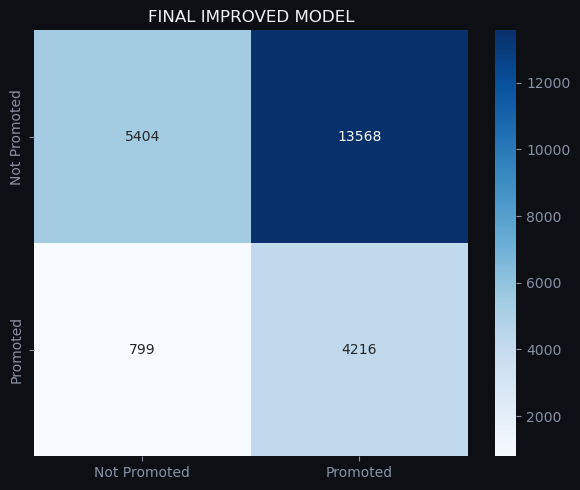


Top Features:

                 Feature  Importance
3              Job_Level    0.229149
0                 Gender    0.156214
7          Annual_Salary    0.143903
8                  Bonus    0.060059
1                    Age    0.053249
11  Parental_Leave_Taken    0.051849
5       Experience_Years    0.051479
4              Education    0.051193
2             Department    0.051168
10        Training_Hours    0.051151
9     Performance_Rating    0.050337
6       Years_at_Company    0.050248


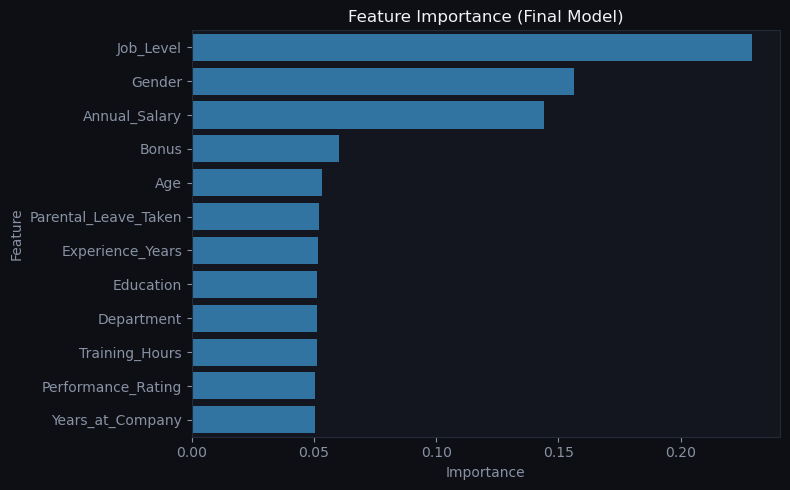


✅ FINAL MODEL COMPLETED SUCCESSFULLY


In [20]:

print("\n" + "="*60)
print("  FINAL IMPROVED MODEL: PROMOTION PREDICTION")
print("="*60)

# -------------------------------
# 1. IMPORTS
# -------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

# -------------------------------
# 2. FEATURES (FIX: remove leakage feature)
# -------------------------------
feature_cols = ['Gender','Age','Department','Job_Level','Education',
                'Experience_Years','Years_at_Company','Annual_Salary',
                'Bonus','Performance_Rating','Training_Hours',
                'Parental_Leave_Taken']   # ❌ removed Leadership_Role

target_col = 'Promoted_Last_Year'

df_model = df[feature_cols + [target_col]].dropna().copy()

# -------------------------------
# 3. LABEL ENCODING
# -------------------------------
cat_cols = ['Gender','Department','Job_Level','Education','Performance_Rating']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# -------------------------------
# 4. SPLIT
# -------------------------------
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# 5. CLASS BALANCE
# -------------------------------
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

# -------------------------------
# 6. FINAL XGBOOST MODEL
# -------------------------------
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# 7. PREDICTIONS
# -------------------------------
y_prob = model.predict_proba(X_test)[:,1]

# 🔥 THRESHOLD TUNING (IMPORTANT)
threshold = 0.42
y_pred = (y_prob >= threshold).astype(int)

# -------------------------------
# 8. EVALUATION
# -------------------------------
roc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print(f"\nROC-AUC: {roc:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['Not Promoted','Promoted']))

# -------------------------------
# 9. CONFUSION MATRIX
# -------------------------------
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Promoted','Promoted'],
            yticklabels=['Not Promoted','Promoted'])

plt.title("FINAL IMPROVED MODEL")
plt.tight_layout()
plt.show()

# -------------------------------
# 10. FEATURE IMPORTANCE
# -------------------------------
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:\n")
print(feat_imp)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance (Final Model)")
plt.tight_layout()
plt.show()

print("\n✅ FINAL MODEL COMPLETED SUCCESSFULLY")



  K-MEANS CLUSTERING (4 Workforce Segments)
                    Count  Avg_Salary  Avg_Experience  Promotion_Rate
Cluster Gender                                                       
0.0     Female      20120    72869.08            8.47            0.00
        Male        12510    87576.32            8.94            0.00
        Non-Binary   1341    71867.46            8.65            0.00
1.0     Female       5744   128874.23           16.21            0.01
        Male        19909   145144.35           16.49            0.02
        Non-Binary    356   126625.08           17.06            0.00
2.0     Female       9877    69005.73            9.02            1.00
        Male        14113    88300.89           10.94            1.00
        Non-Binary    733    69022.83            9.14            1.00
3.0     Female      14781    72084.80            7.05            0.00
        Male        19405    87255.04            7.56            0.00
        Non-Binary   1043    70834.18        

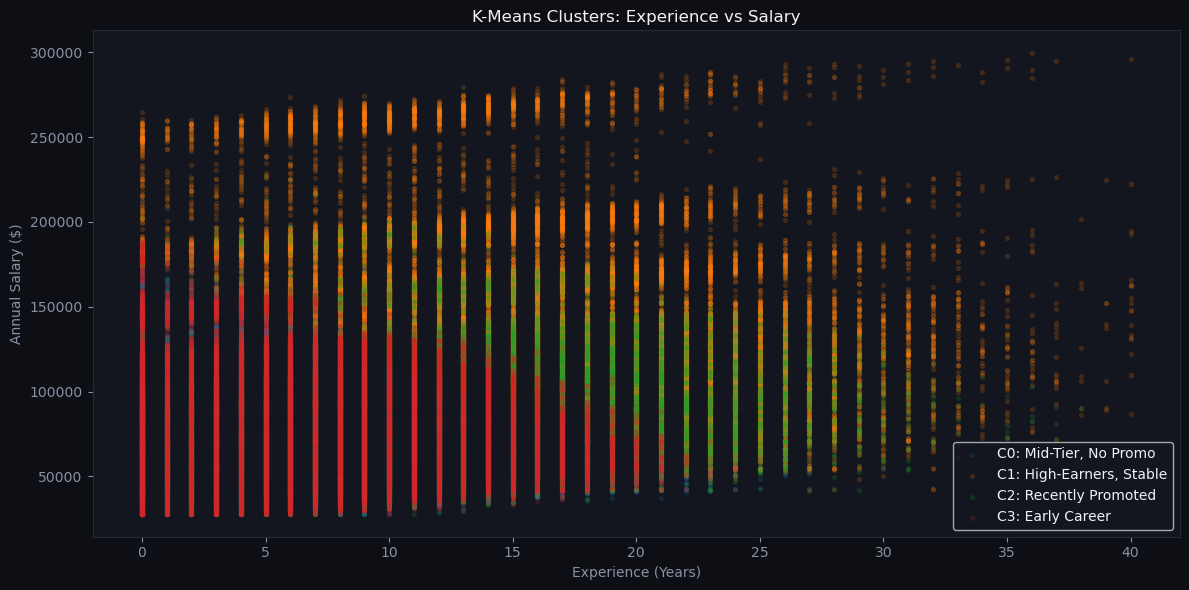

In [15]:
print("\n" + "="*60)
print("  K-MEANS CLUSTERING (4 Workforce Segments)")
print("="*60)

cluster_feats = ['Annual_Salary','Experience_Years','Training_Hours','Promoted_Last_Year']
cdf = df[cluster_feats].dropna().copy()
sc2 = StandardScaler()
X_cl = sc2.fit_transform(cdf)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[cdf.index, 'Cluster'] = km.fit_predict(X_cl)

cluster_summary = df.groupby(['Cluster','Gender']).agg(
    Count=('Annual_Salary','count'),
    Avg_Salary=('Annual_Salary','mean'),
    Avg_Experience=('Experience_Years','mean'),
    Promotion_Rate=('Promoted_Last_Year','mean')
).round(2)
print(cluster_summary)

cluster_names = {0:'Mid-Tier, No Promo', 1:'High-Earners, Stable', 2:'Recently Promoted', 3:'Early Career'}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in cluster_names.items():
    subset = df[df['Cluster'] == i]
    ax.scatter(subset['Experience_Years'], subset['Annual_Salary'], alpha=0.15, s=8, label=f'C{i}: {name}')
ax.set_xlabel('Experience (Years)'); ax.set_ylabel('Annual Salary ($)')
ax.set_title('K-Means Clusters: Experience vs Salary'); ax.legend()
plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
print("✅ Clustering plot saved")